In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Задание 1: Импорт набора Fashion MNIST
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images_f, train_labels_f), (test_images_f, test_labels_f) = fashion_mnist.load_data()

# Названия классов одежды
class_names_f = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Обучающая выборка: {train_images_f.shape}")
print(f"Тестовая выборка: {test_images_f.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Обучающая выборка: (60000, 28, 28)
Тестовая выборка: (10000, 28, 28)


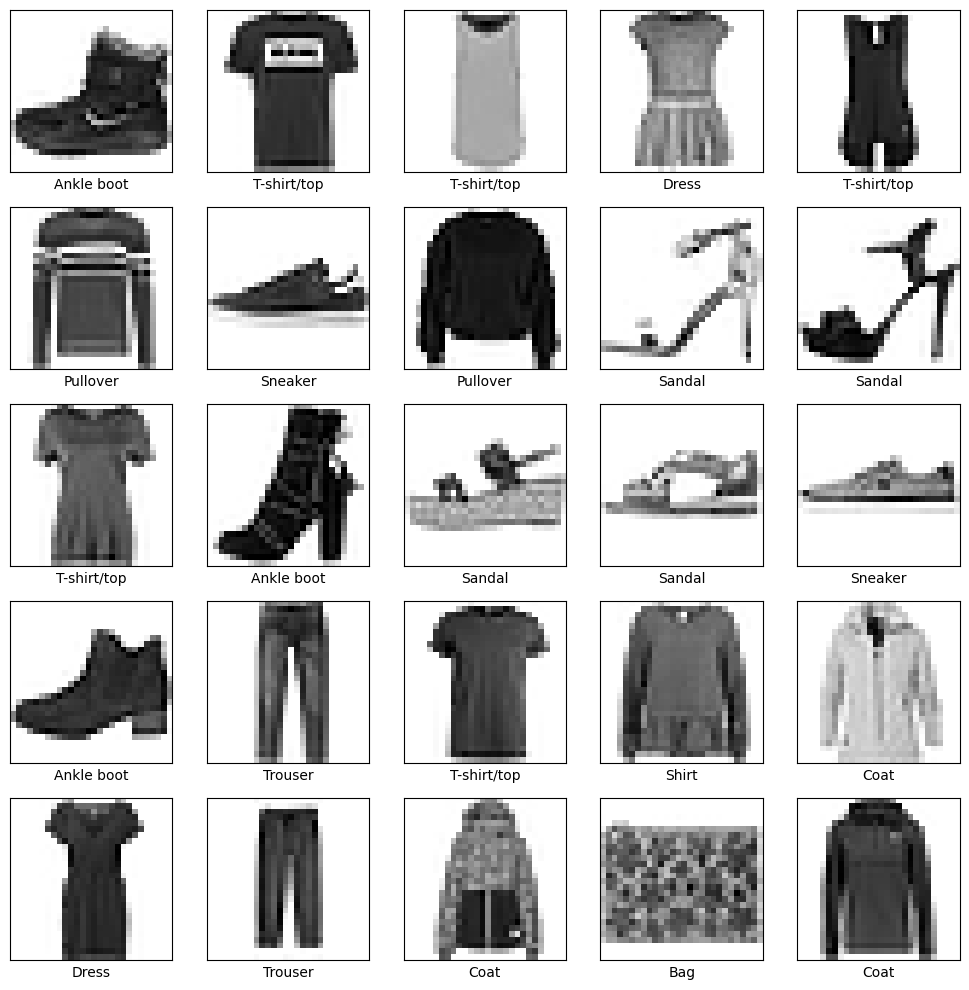

In [ ]:
# Масштабирование пикселей в диапазон [0, 1]
train_images_f = train_images_f / 255.0
test_images_f = test_images_f / 255.0

# Визуализация первых 25 изображений из обучающей выборки
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images_f[i], cmap=plt.cm.binary)
    plt.xlabel(class_names_f[train_labels_f[i]])
plt.tight_layout()
plt.show()

In [ ]:
# Создание модели 
model_f = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)  
])

# Компиляция
model_f.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])
model_f.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history_f = model_f.fit(train_images_f, train_labels_f, epochs=10, validation_split=0.1, verbose=1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 582us/step - accuracy: 0.6379 - loss: 1.1572 - val_accuracy: 0.7463 - val_loss: 0.7366
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 556us/step - accuracy: 0.7604 - loss: 0.6708 - val_accuracy: 0.7775 - val_loss: 0.6080
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step - accuracy: 0.7880 - loss: 0.5874 - val_accuracy: 0.8027 - val_loss: 0.5524
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 562us/step - accuracy: 0.8080 - loss: 0.5409 - val_accuracy: 0.8167 - val_loss: 0.5199
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 545us/step - accuracy: 0.8199 - loss: 0.5108 - val_accuracy: 0.8222 - val_loss: 0.4990
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 556us/step - accuracy: 0.8288 - loss: 0.4895 - val_accuracy: 0.8278 - val_loss: 0.4816
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 554us/step - accuracy: 0.8332 - loss: 0.4739 - val_accuracy: 0.8327 - val_loss: 0.4643
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 575us/step - accuracy: 0.8384 -

In [ ]:
# Оценка на тестовом наборе
test_loss_f, test_acc_f = model_f.evaluate(test_images_f, test_labels_f, verbose=2)

# Ошибка классификации (Error Rate)
classification_error_f = 1.0 - test_acc_f

print(f"\nFashion MNIST - Результаты:")
print(f"Accuracy: {test_acc_f:.4f} ({test_acc_f*100:.2f}%)")
print(f"Error Rate: {classification_error_f:.4f} ({classification_error_f*100:.2f}%)")

313/313 - 0s - 305us/step - accuracy: 0.8322 - loss: 0.4698

Fashion MNIST - Результаты:
Accuracy: 0.8322 (83.22%)
Error Rate: 0.1678 (16.78%)


In [ ]:
def plot_image_f(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(class_names_f[predicted_label],
                                         100*np.max(predictions_array),
                                         class_names_f[true_label]),
               color=color)

def plot_value_array_f(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 255us/step


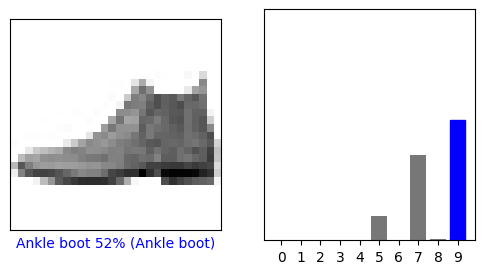

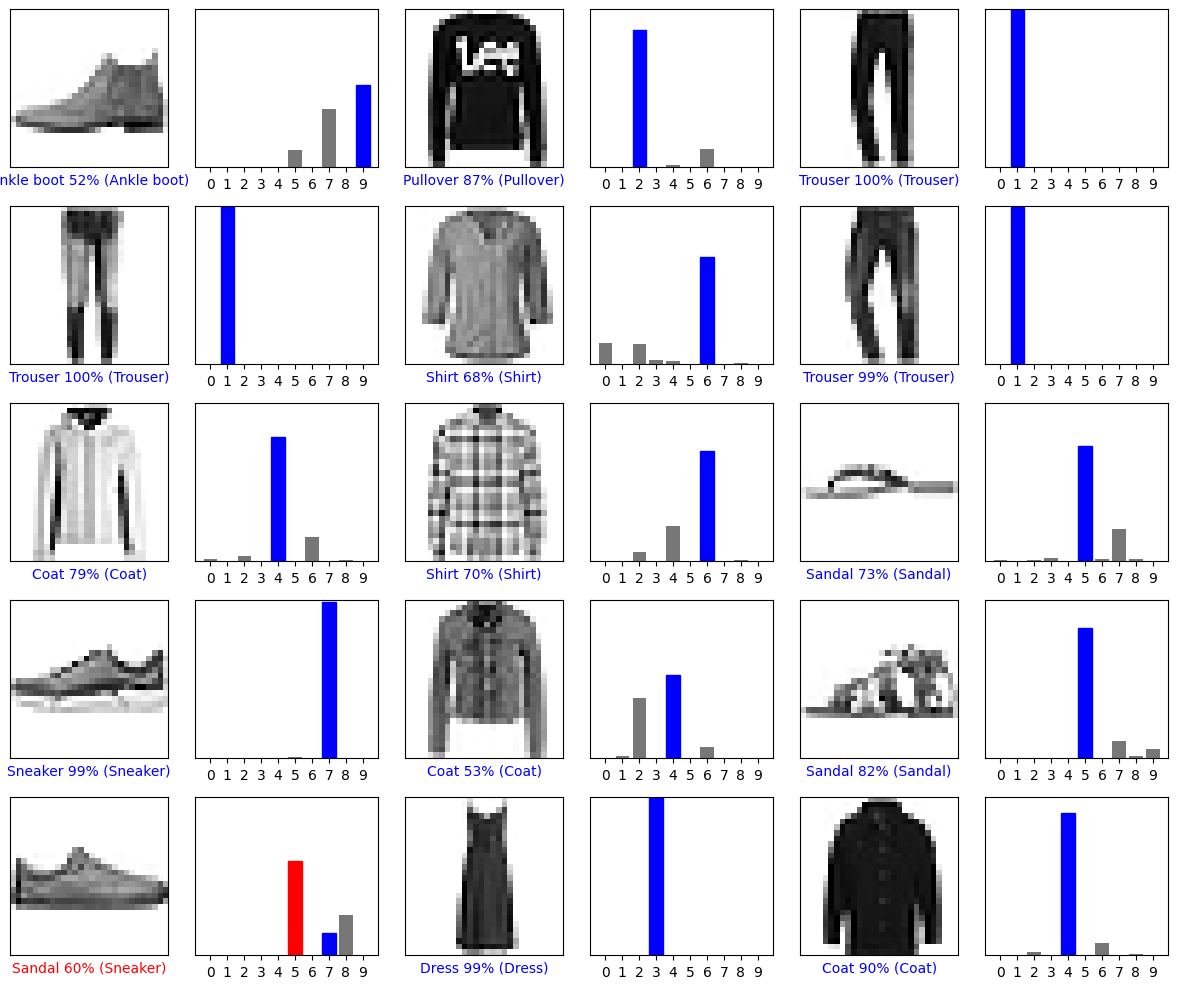

In [ ]:
probability_model_f = tf.keras.Sequential([model_f, tf.keras.layers.Softmax()])
predictions_f = probability_model_f.predict(test_images_f)

i = 0  
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image_f(i, predictions_f[i], test_labels_f, test_images_f)
plt.subplot(1,2,2)
plot_value_array_f(i, predictions_f[i], test_labels_f)
plt.show()

# Массовая визуализация (5 строк, 3 колонки)
num_rows, num_cols = 5, 3
num_images = num_rows * num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image_f(i, predictions_f[i], test_labels_f, test_images_f)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array_f(i, predictions_f[i], test_labels_f)
plt.tight_layout()
plt.show()

**Задание 2**
---

In [ ]:
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

class_names = [str(i) for i in range(10)]

train_images = train_images / 255.0
test_images = test_images / 255.0

print(f"Размер обучающей выборки: {train_images.shape}")
print(f"Размер тестовой выборки: {test_images.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Размер обучающей выборки: (60000, 28, 28)
Размер тестовой выборки: (10000, 28, 28)


In [ ]:

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)  
])


model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history = model.fit(train_images, train_labels, epochs=10, validation_split=0.1, verbose=1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 587us/step - accuracy: 0.9885 - loss: 0.0374 - val_accuracy: 0.9758 - val_loss: 0.0805
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 560us/step - accuracy: 0.9912 - loss: 0.0291 - val_accuracy: 0.9762 - val_loss: 0.0796
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 559us/step - accuracy: 0.9928 - loss: 0.0240 - val_accuracy: 0.9810 - val_loss: 0.0756
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 572us/step - accuracy: 0.9943 - loss: 0.0197 - val_accuracy: 0.9782 - val_loss: 0.0795
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 554us/step - accuracy: 0.9948 - loss: 0.0171 - val_accuracy: 0.9780 - val_loss: 0.0888
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 607us/step - accuracy: 0.9960 - loss: 0.0132 - val_accuracy: 0.9788 - val_loss: 0.0827
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 565us/step - accuracy: 0.9964 - loss: 0.0116 - val_accuracy: 0.9775 - val_loss: 0.0910
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 550us/step - accuracy: 0.9965 -

In [ ]:
# Оценка на тестовом наборе
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

# Вычисление ошибки классификации
classification_error = 1.0 - test_acc

print(f"\n📊 Результаты на тестовой выборке:")
print(f"✅ Точность (Accuracy): {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"❌ Ошибка вычисления (Error Rate): {classification_error:.4f} ({classification_error*100:.2f}%)")
print(f"📉 Функция потерь (Loss): {test_loss:.4f}")

313/313 - 0s - 309us/step - accuracy: 0.9789 - loss: 0.0912

📊 Результаты на тестовой выборке:
✅ Точность (Accuracy): 0.9789 (97.89%)
❌ Ошибка вычисления (Error Rate): 0.0211 (2.11%)
📉 Функция потерь (Loss): 0.0912


In [ ]:
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                         100*np.max(predictions_array),
                                         class_names[true_label]),
               color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 250us/step


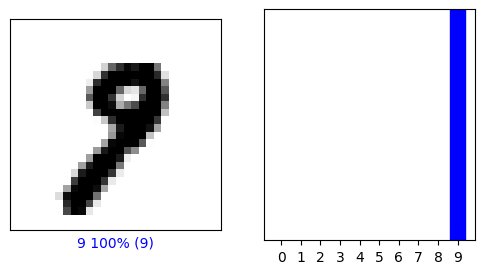

In [ ]:
# Оборачиваем модель в Softmax для получения вероятностей
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])

# Предсказания на всем тестовом наборе
predictions = probability_model.predict(test_images)

# Выбор изображения для проверки (например, индекс 73)
i = 73

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()

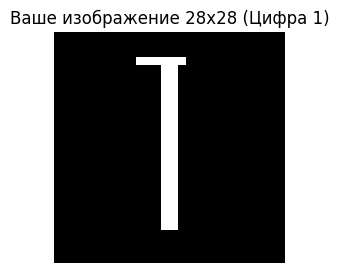

In [ ]:
# Создаём простое изображение цифры "1" программно (белый фон=0, линия=1)
custom_img = np.zeros((28, 28), dtype=np.float32)

custom_img[4:24, 13:15] = 1.0

custom_img[3:4, 10:16] = 1.0

# Визуализация созданного изображения
plt.figure(figsize=(3,3))
plt.imshow(custom_img, cmap='gray')
plt.title("Ваше изображение 28x28 (Цифра 1)")
plt.axis('off')
plt.show()



In [ ]:
# Добавляем измерение batch (модель ожидает размерность [batch, 28, 28])
custom_img_batch = np.expand_dims(custom_img, axis=0)
print(f"Размер тензора для модели: {custom_img_batch.shape}")

# Получаем предсказание
custom_prediction = probability_model.predict(custom_img_batch)
predicted_class = np.argmax(custom_prediction[0])

print(f"\n🔍 Распределение вероятностей:\n{custom_prediction[0]}")
print(f"🎯 Модель предсказала класс: {predicted_class} (Цифра: {predicted_class})")

🎨 ИНСТРУКЦИЯ:
1. Рисуйте БЕЛЫМ на ЧЁРНОМ фоне (как на чёрной доске).
2. Цифра должна быть по центру, не касаясь краёв.
3. Нажмите 'Предсказать'.



📁 АЛЬТЕРНАТИВА (если холст не сработал):


FileUpload(value=(), accept='image/*', description='Upload')